# SN2N Prediction Results (2D TIFF)


**What you will edit:** Base directory path


## Outline

1. Setup and configuration
2. Loading the model & Training curves
3. Metrics used for evaluation (RSP, RSE, SSIM)
4. Predict + evaluate a single image
5. Batch evaluation on the full test set


## 1) Setup and data layout

This notebook expects the SN2N code to be available locally (for example containing `improved_trainer.py` and `get_options.py`).

It also assumes your data has already been **preprocessed into paired patches** for training/validation.

- `train` folder: paired training patches
- `val1` folder: paired validation patches (used for validation loss)
- `test_gt_mapping.csv`: mapping from each test image to its ground truth (GT)

> Tip: keep paths in one place (the config cell below) so you do not have to hunt through the notebook later.


### Key training parameters

- `img_path`: path to the training patches directory
- `val_path`: path to the validation patches directory
- `sn2n_loss`: weight of the self-constrained loss (typically in the range `0` to `2`)
- `bs`: batch size
- `lr`: learning rate
- `epochs`: max epochs (use early stopping if available)

Other parameters are usually left at defaults (see `trainer2D` / SN2N options in your repo).


In [1]:
# Set your base directory ONCE here
BASE_DIR = r'C:/Users/ntpar/Downloads/SN2N_Capstone/'

# Imports
import os
import sys
import gc
import random
import importlib
from pathlib import Path
from typing import Optional, Tuple
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tifffile
import torch
from tqdm.auto import tqdm

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# --- Local SN2N modules ---
# Option A: set an environment variable SN2N_PROJECT_ROOT
# Option B: edit PROJECT_ROOT below.
PROJECT_ROOT = Path(os.environ.get('SN2N_PROJECT_ROOT', f'{BASE_DIR}/SN2N-refactored'))

# Point directly to your patch folders using BASE_DIR
img_path = f'{BASE_DIR}/splits/preprocessed-p2p/train'
val_path = f'{BASE_DIR}/splits/preprocessed-p2p/val1'

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


try:
    import improved_trainer
    importlib.reload(improved_trainer)  # pick up edits without restarting kernel
    from improved_trainer import net2D
    from get_options import trainer2D
    import eval_utils
    import plotting_utils

    # Metrics helpers (moved to metrics_utils.py)
    from metrics_utils import (
        fit_affine_percentiles,
        apply_affine,
        fit_alpha_beta,
        squirrel_rsp_rse,
        squirrel_ssim,
        add_metrics_labels_ssim,
    )
    from eval_utils import process_test_set_with_model

    # Dataset mapping + evaluation helpers (moved to eval_utils.py)
    from eval_utils import (
        load_and_standardize_mapping,
        process_val2_with_model,
        summarize_metrics,
        score_from_metrics,
        hyperparameter_search_train_val1_eval_val2,
    )

except Exception as e:
    raise ImportError(
        'Could not import SN2N modules (improved_trainer.py, get_options.py).\n'
        'Edit PROJECT_ROOT above or set SN2N_PROJECT_ROOT, then re-run this cell.'
    ) from e

print('PROJECT_ROOT:', PROJECT_ROOT)
print('Torch device:', 'cuda' if torch.cuda.is_available() else 'cpu')


c:\Users\ntpar\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PROJECT_ROOT: C:\Users\ntpar\Downloads\SN2N_Capstone\SN2N-refactored
Torch device: cuda


## 2) Loading the model

In [3]:
# Key hyperparameters
sn2n_loss = 2
lambda_grad = 0.3
bs = 52
lr = 2e-4
q = 0.9
epochs = 1
patience = 10

# Build args namespace using trainer2D for consistency with the SN2N repo
trainer2D_args = [
    '--img_path', img_path,
    '--sn2n_loss', str(sn2n_loss),
    '--bs', str(bs),
    '--lr', str(lr),
    '--epochs', str(epochs),
]

args = trainer2D(trainer2D_args)

# Ensure correct types
args.sn2n_loss = float(args.sn2n_loss)
args.bs = int(args.bs)
args.lr = float(args.lr)
args.epochs = int(args.epochs)

# Some trainer versions do not expose val_path via parser; we attach it here.
args.val_path = val_path
args.val_bs = args.bs
args.q = q
args.patience = patience

model_path = BASE_DIR / Path(r'Visualization/bestmodel.pth')

# Create a model wrapper 
sn2nunet = net2D(
    img_path=args.img_path,
    sn2n_loss=args.sn2n_loss,
    bs=args.bs,
    lr=args.lr,
    epochs=args.epochs,
    img_patch='249',
    val_path=getattr(args, 'val_path', None),
    val_bs=getattr(args, 'val_bs', None),
    early_stop=True,
    patience=args.patience,
    lambda_grad=lambda_grad,
    q=getattr(args, 'q', 0.8),
)

if model_path.exists():
    print(f'Loading model from: {model_path}')
    checkpoint = torch.load(model_path, map_location=sn2nunet.device, weights_only=False)

    if isinstance(checkpoint, torch.nn.Module):
        sn2nunet.model = checkpoint
    elif isinstance(checkpoint, dict):
        state_dict = checkpoint.get('model_state_dict') or checkpoint.get('state_dict') or checkpoint
        sn2nunet.model.load_state_dict(state_dict)
    else:
        raise TypeError(f'Unexpected checkpoint type: {type(checkpoint)}')

    sn2nunet.model.to(sn2nunet.device)
    sn2nunet.model.eval()
    print('Loaded and ready.')
else:
    raise FileNotFoundError(f'Model file not found: {model_path}')


Loading model from: C:\Users\ntpar\Downloads\SN2N_Capstone\Visualization\bestmodel.pth
Loaded and ready.


### Training diagnostics 

If your trainer returns loss curves, the next cell will plot them.


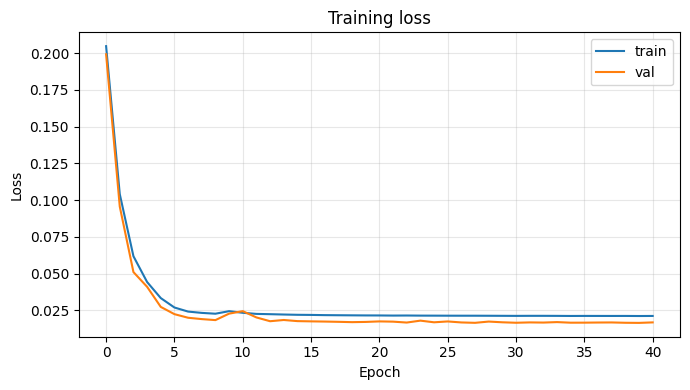

In [4]:
from plotting_utils import plot_loss_curve

file_path = BASE_DIR / Path(r'Visualization/loss_best.txt')
with open(file_path, 'r') as f:
    loss_history = [float(line.strip()) for line in f if line.strip()]

file_path = BASE_DIR / Path(r'Visualization/val_best.txt')
if os.path.exists(file_path):
    with open(file_path, 'r') as f:
        val_loss_history = [float(line.strip()) for line in f if line.strip()]

plot_loss_curve(loss_history, val_loss_history)


## 3) Metrics and normalization

This notebook computes:

- **RSP**: Pearson correlation between prediction and GT (higher is better)
- **RSE**: RMSE between prediction and GT (lower is better)
- **SSIM**: structural similarity index (higher is better)

We percentile-normalize the GT (default 1.0 to 99.5 percentiles). For RSP/RSE/SSIM, we optionally fit an affine intensity transform (alpha, beta) to align prediction with GT.


## 4) Predict and evaluate a single test image

The cell will:

1. Load the images
2. Run the SN2N model
3. Compute metrics
4. Show GT / raw / prediction side-by-side


Shapes - GT: (249, 249), Raw: (249, 249)
Prediction shape: (249, 249)

Metrics comparison:
  SOFI+RL         - RSP: 0.8972, RSE: 0.083289, SSIM: 0.6421, alpha: 1.0080, beta: -0.0460
  SN2N prediction - RSP: 0.9085, RSE: 0.078833, SSIM: 0.7020, alpha: 1.0612, beta: -0.0512


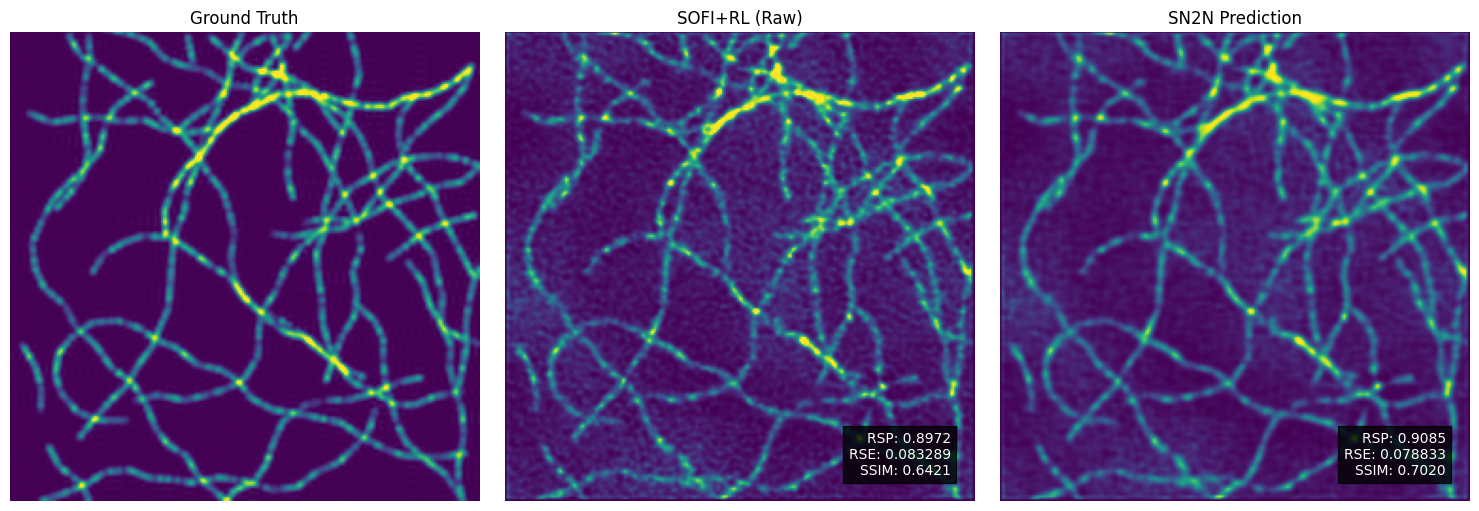

In [5]:

# Ensure model is available
if 'sn2nunet' not in globals():
    raise RuntimeError("sn2nunet is not defined; train a model or load a checkpoint first.")

sn2nunet.model.eval()

raw_path = BASE_DIR / Path(r'splits/preprocessed-p2p/test/08_047_02_noisyvid__mctsofi_c2_RL.tif')
gt_path  = BASE_DIR / Path(r'data/08_Dens3000_b32_filtWilly/047_Training_/GT/ConvDownUp/Rescaled_GT/2o_Training__GTconvres_135nm.tif')

for p in (raw_path, gt_path):
    if not p.exists():
        raise FileNotFoundError(f'File not found: {p}')

raw = tifffile.imread(raw_path)
if raw.ndim > 2:
    raw = raw[0]
raw = raw.astype(np.float32)

GT = tifffile.imread(gt_path)
if GT.ndim > 2:
    GT = GT[0]
GT = GT.astype(np.float32)

print(f'Shapes - GT: {GT.shape}, Raw: {raw.shape}')

pred_t = sn2nunet.test(raw)
pred = np.squeeze(pred_t.detach().cpu().numpy()).astype(np.float32)

print(f'Prediction shape: {pred.shape}')

# Normalize GT percentiles; raw/pred are assumed already in the correct scale
lo, hi = fit_affine_percentiles(GT)
GT_norm = apply_affine(GT, lo, hi)


# Calculate SQUIRREL-style metrics (sigma=1.0)
raw_s_rsp, raw_s_rse, raw_a, raw_b = squirrel_rsp_rse(raw, GT_norm)
pred_s_rsp, pred_s_rse, pred_a, pred_b = squirrel_rsp_rse(pred, GT_norm)

# Calculate SSIM with affine fit and clipping to GT range
raw_ssim, _, _ = squirrel_ssim(raw, GT_norm, intensity_fit=True, clip_to_gt=True)
pred_ssim, _, _ = squirrel_ssim(pred, GT_norm, intensity_fit=True, clip_to_gt=True)

print("\nMetrics comparison:")
print(f"  SOFI+RL         - RSP: {raw_s_rsp:.4f}, RSE: {raw_s_rse:.6f}, SSIM: {raw_ssim:.4f}, alpha: {raw_a:.4f}, beta: {raw_b:.4f}")
print(f"  SN2N prediction - RSP: {pred_s_rsp:.4f}, RSE: {pred_s_rse:.6f}, SSIM: {pred_ssim:.4f}, alpha: {pred_a:.4f}, beta: {pred_b:.4f}")

# Visualize
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

axs[0].imshow(GT_norm, cmap='viridis')
axs[0].set_title('Ground Truth')
axs[0].axis('off')

axs[1].imshow(raw, cmap='viridis')
axs[1].set_title('SOFI+RL (Raw)')
axs[1].axis('off')
add_metrics_labels_ssim(axs[1], raw_s_rsp, raw_s_rse, raw_ssim)

axs[2].imshow(pred, cmap='viridis')
axs[2].set_title('SN2N Prediction')
axs[2].axis('off')
add_metrics_labels_ssim(axs[2], pred_s_rsp, pred_s_rse, pred_ssim)
plt.tight_layout()
plt.show()



## 5) Batch evaluation on the test set

This section evaluates **all test images with available GT** using a mapping CSV produced by preprocessing.

Expected columns in the mapping CSV:

- `test_path` (path to test image)
- `gt_path` (path to GT)
- `gt_exists` (True/False)
- `test_file` (optional, file name)

If your CSV uses different column names, either rename columns or use the standardization helper in the hyperparameter section.


### Visualize batch results

Boxplots compare raw (SOFI+RL) vs SN2N across the dataset.


Loaded results: C:\Users\ntpar\Downloads\SN2N_Capstone\Visualization\test_metrics_results.csv (modified 2026-01-21T11:10:08)


C:\Users\ntpar\AppData\Local\Temp\ipykernel_28200\2058115231.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([df_success['sofi_s_rsp'], df_success['sn2n_s_rsp']], labels=['SOFI+RL', 'SN2N'])
C:\Users\ntpar\AppData\Local\Temp\ipykernel_28200\2058115231.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([df_success['sofi_s_rse'], df_success['sn2n_s_rse']], labels=['SOFI+RL', 'SN2N'])
C:\Users\ntpar\AppData\Local\Temp\ipykernel_28200\2058115231.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot([df_success['sofi_ssim'], df_success['sn2n_ssim']], labels=['SOFI+RL', 

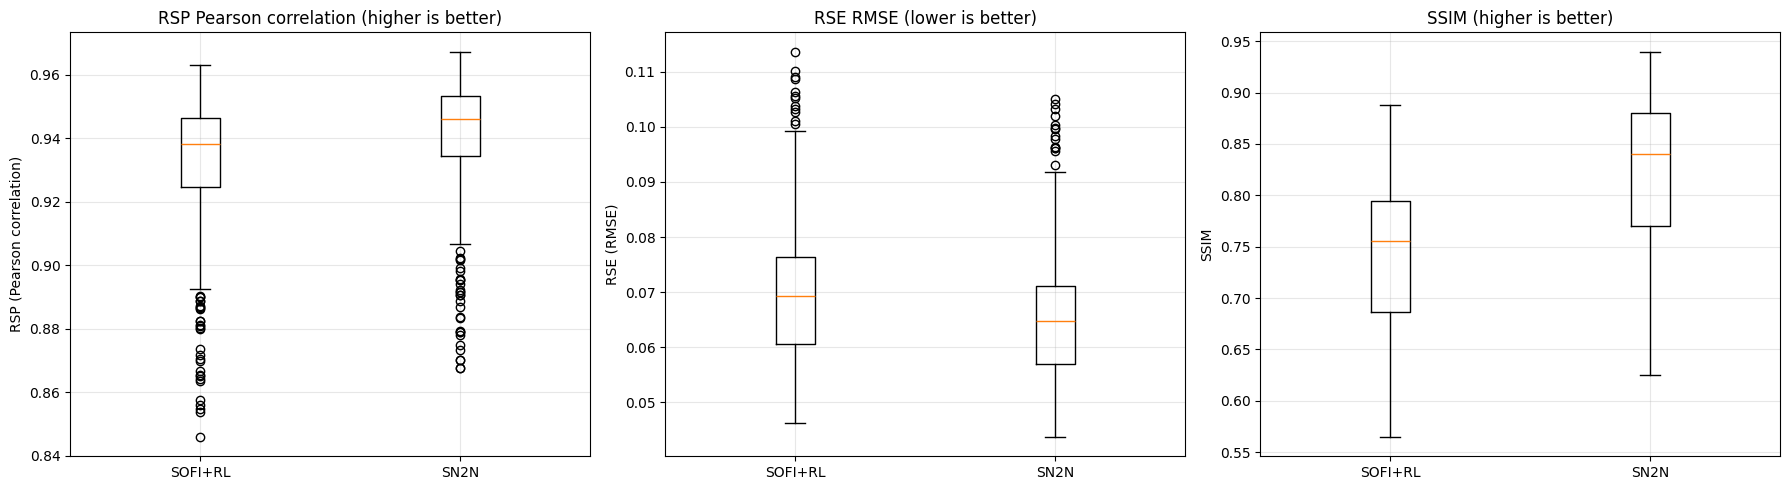


Images showing improvement:
  RSP: 299/300 (99.7%)
  RSE: 299/300 (99.7%)
  SSIM: 300/300 (100.0%)


In [6]:
# Load the results
results_csv = BASE_DIR / Path(r'Visualization/test_metrics_results.csv') 

if results_csv.exists():
    mtime = datetime.fromtimestamp(results_csv.stat().st_mtime)
    print(f"Loaded results: {results_csv} (modified {mtime.isoformat(timespec='seconds')})")
    df_results = pd.read_csv(results_csv)
else:
    raise FileNotFoundError(f"Results file not found at {results_csv}")

# Filter successful results
df_success = df_results[df_results['status'] == 'success'].copy()

if len(df_success) > 0:
    # SQUIRREL RSP/RSE/SSIM comparisons
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    # RSP boxplot
    axes[0].boxplot([df_success['sofi_s_rsp'], df_success['sn2n_s_rsp']], labels=['SOFI+RL', 'SN2N'])
    axes[0].set_ylabel('RSP (Pearson correlation)')
    axes[0].set_title('RSP Pearson correlation (higher is better)')
    axes[0].grid(True, alpha=0.3)
    # RSE boxplot
    axes[1].boxplot([df_success['sofi_s_rse'], df_success['sn2n_s_rse']], labels=['SOFI+RL', 'SN2N'])
    axes[1].set_ylabel('RSE (RMSE)')
    axes[1].set_title('RSE RMSE (lower is better)')
    axes[1].grid(True, alpha=0.3)
    # SSIM boxplot
    axes[2].boxplot([df_success['sofi_ssim'], df_success['sn2n_ssim']], labels=['SOFI+RL', 'SN2N'])
    axes[2].set_ylabel('SSIM')
    axes[2].set_title('SSIM (higher is better)')
    axes[2].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    # Count how many images improved (SQUIRREL/SSIM)
    s_rsp_improved = (df_success['s_rsp_improvement'] > 0).sum()
    s_rse_improved = (df_success['s_rse_improvement'] > 0).sum()
    ssim_improved = (df_success['ssim_improvement'] > 0).sum()
    print(f"\nImages showing improvement:")
    print(f"  RSP: {s_rsp_improved}/{len(df_success)} ({100*s_rsp_improved/len(df_success):.1f}%)")
    print(f"  RSE: {s_rse_improved}/{len(df_success)} ({100*s_rse_improved/len(df_success):.1f}%)")
    print(f"  SSIM: {ssim_improved}/{len(df_success)} ({100*ssim_improved/len(df_success):.1f}%)")
else:
    print("No data to visualize.")